#### Instructions
###### Follow the instructions given in comments prefixed with ## and write your code below that.
###### Also fill the partial code in given blanks. 
###### Don't make any changes to the rest part of the codes

### Answer the questions given at the end of this notebook within your report.

### You would need to submit your GitHub repository link. Refer to the PDF document for the instructions and details.





In [8]:
## import cv2
## import numpy
## import matplotlib pyplot
## import KMeans cluster from sklearn
## import distance from scipy.spatial
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial import distance

In [9]:
## Reading the image plaksha_Faculty.jpg
img = cv2.imread(r"C:\Users\adhwa\Downloads\Plaksha_Faculty.jpg")  
## Convert the image to grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  
# Loading the required haar-cascade xml classifier file
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)
  
# Applying the face detection method on the grayscale image. 
## Change the parameters for better detection of faces in your case.
faces_rect = face_cascade.detectMultiScale(gray_img, 1.05, 4, minSize=(25,25), maxSize=(50,50))
 
# Define the text and font parameters
text = "Face" ## The text you want to write
font = cv2.FONT_HERSHEY_SIMPLEX ## Font type
font_scale = 0.5  ## Font scale factor
font_color = (0, 0, 255)  ## Text color in BGR format (here, it's red)
font_thickness = 1  ## Thickness of the text

  
# Iterating through rectangles of detected faces
for (x, y, w, h) in faces_rect:
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 0, 255), 2)
    # Use cv2.putText to add the text to the image, Use text, font, font_scale, font_color, font_thickness here
    cv2.putText(img, text, (x, y - 5), font, font_scale, font_color, font_thickness)
    
## Display the image and window title should be "Total number of face detected are #"  
cv2.imshow(f"Total number of face detected are {len(faces_rect)}", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [15]:
print(faces_rect)
print(len(faces_rect))

[[ 632  328   34   34]
 [ 322  263   33   33]
 [ 819  337   33   33]
 [ 654  265   31   31]
 [ 500  266   30   30]
 [ 892  267   31   31]
 [ 576  253   32   32]
 [ 893  327   36   36]
 [ 477  407   36   36]
 [ 158  389   42   42]
 [ 731  316   40   40]
 [ 812  274   34   34]
 [1003  273   32   32]
 [ 262  410   41   41]
 [ 675  413   37   37]
 [1072  410   42   42]
 [ 975  416   40   40]
 [ 870  424   35   35]
 [ 364  424   40   40]
 [ 570  426   39   39]
 [1019  348   40   40]
 [ 925  353   38   38]
 [ 777  390   45   45]
 [ 732  278   33   33]
 [ 262  275   43   43]
 [ 409  277   28   28]
 [1095  361   33   33]
 [ 464  296   33   33]
 [ 359  300   33   33]
 [ 547  300   34   34]]
30


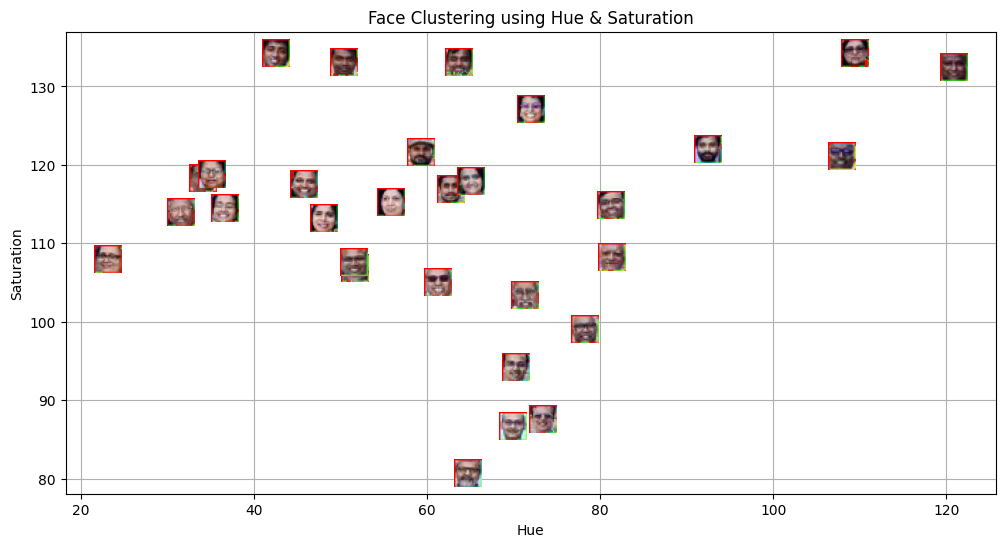

In [17]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
# Extract face region features (Hue and Saturation)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV) ## call the img and convert it from BGR to HSV and store in img_hsv
hue_saturation = []
face_images = []  # To store detected face images

for (x, y, w, h) in faces_rect:
    face = img_hsv[y:y + h, x:x + w]
    hue = np.mean(face[:, :, 0])
    saturation = np.mean(face[:, :, 1])
    hue_saturation.append((hue, saturation))
    face_images.append(face)

hue_saturation = np.array(hue_saturation)

## Perform k-Means clustering on hue_saturation and store in kmeans
kmeans =  KMeans(n_clusters=3, random_state=42).fit(hue_saturation)
#centroids = kmeans.cluster_centers_
#labels = kmeans.labels_

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the clustered faces with custom markers
for i, (x,y,w,h ) in enumerate(faces_rect):
    im = OffsetImage(cv2.cvtColor(cv2.resize(face_images[i], (20, 20)), cv2.COLOR_HSV2RGB))
    ab = AnnotationBbox(im, (hue_saturation[i, 0], hue_saturation[i, 1]), frameon=False, pad=0)
    ax.add_artist(ab)
    plt.plot(hue_saturation[i, 0], hue_saturation[i, 1])
    

## Put x label
## Put y label
## Put title
## Put grid
## show the plot
plt.xlabel("Hue")
plt.ylabel("Saturation")
plt.title("Face Clustering using Hue & Saturation")
plt.grid(True)
plt.scatter(hue_saturation[:,0], hue_saturation[:,1], alpha=0)
plt.show()

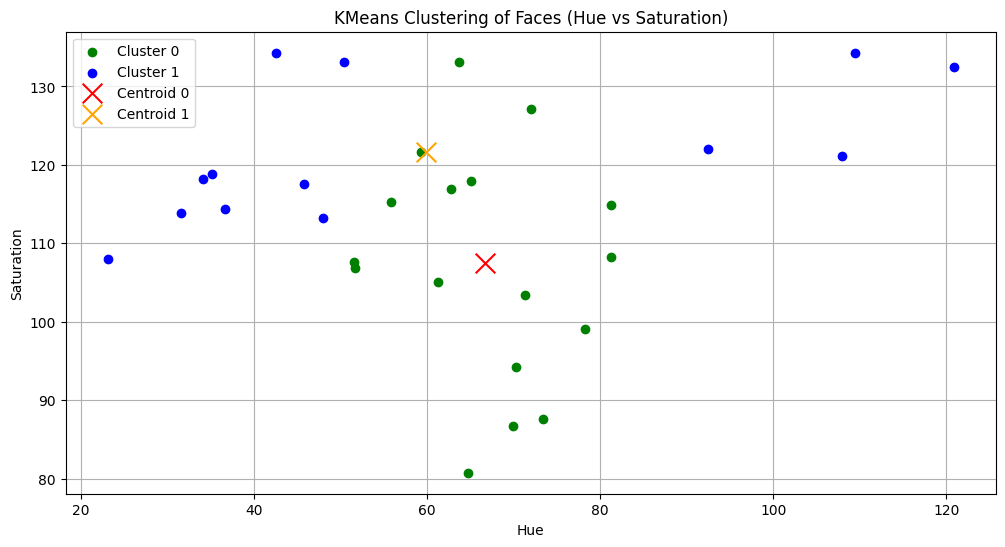

In [7]:
# Create an empty list to store legend labels
legend_labels = []

# Create lists to store points for each cluster
cluster_0_points = []
cluster_1_points = []

# Your code for scatter plot goes here
fig, ax = plt.subplots(figsize=(12, 6))
for i, (x, y, w, h) in enumerate(faces_rect):
    if kmeans.labels_[i] == 0:
        cluster_0_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))
    else:
        cluster_1_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))


cluster_0_points = np.array(cluster_0_points)
# Plot points for cluster 0 in green
plt.scatter(cluster_0_points[:, 0], cluster_0_points[:, 1], color='green', label='Cluster 0')


cluster_1_points = np.array(cluster_1_points)
# Plot points for cluster 1 in blue
plt.scatter(cluster_1_points[:, 0], cluster_1_points[:, 1], color='blue', label='Cluster 1')

# Calculate and plot centroids
centroid_0 = np.mean(cluster_0_points, axis=0)
centroid_1 = np.mean(cluster_1_points, axis=0)

# Plot both the centroid for cluster 0 and cluster 1 
plt.scatter(centroid_0[0], centroid_0[1], marker='x', s=200, color='red', label='Centroid 0')
plt.scatter(centroid_1[0], centroid_1[1], marker='x', s=200, color='orange', label='Centroid 1')

## Put x label
## Put y label
## Put title
## Add a legend
## Add grid
## Show the plot

plt.xlabel("Hue")
plt.ylabel("Saturation")
plt.title("KMeans Clustering of Faces (Hue vs Saturation)")
plt.legend()
plt.grid(True)
plt.show()


In [25]:
## Read the class of the template image 'Dr_Shashi_Tharoor.jpg' using cv2 and store it in template_img
template_img = cv2.imread(r"Dr_Shashi_Tharoor.jpg")
# Detect face  in the template image after converting it to gray and store it in template_faces
template_img = cv2.imread(r"C:\Users\adhwa\Downloads\Dr_Shashi_Tharoor.jpg")
template_faces = face_cascade.detectMultiScale(
    cv2.cvtColor(template_img, cv2.COLOR_BGR2GRAY),
    scaleFactor=1.3,
    minNeighbors=5
)
# Draw rectangles around the detected faces
for (x, y, w, h) in template_faces:
    cv2.rectangle(template_img, (x, y), (x + w, y + h), (0, 255, 0), 3)
cv2.imshow("Template Faces", template_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

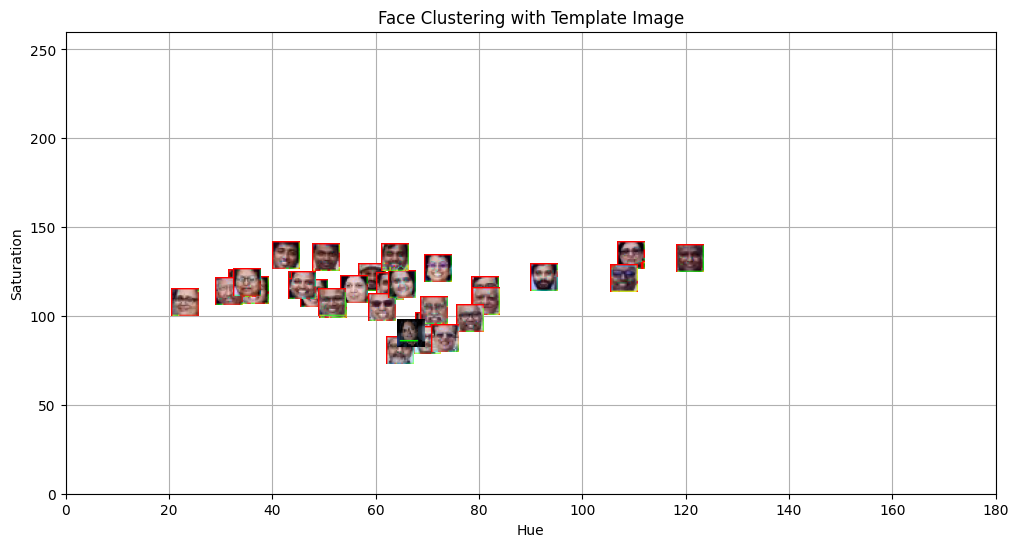

In [27]:
# Convert the template image to HSV color space and store it in template_hsv
template_hsv = cv2.cvtColor(template_img, cv2.COLOR_BGR2HSV)

# Extract hue and saturation features from the template image as we did it for detected faces.
template_hue = np.mean(template_hsv[:, :, 0])
template_saturation = np.mean(template_hsv[:, :, 1])

# Predict the cluster label for the template image and store it in template_label
template_label = kmeans.predict([[template_hue, template_saturation]])[0]

# Create a figure and axis for visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the clustered faces with custom markers (similar to previous code)
for i, (x, y, w, h) in enumerate(faces_rect):
    color = 'red' if kmeans.labels_[i] == 0 else 'blue'
    im = OffsetImage(cv2.cvtColor(cv2.resize(face_images[i], (20, 20)), cv2.COLOR_HSV2RGB))
    ab = AnnotationBbox(im, (hue_saturation[i, 0], hue_saturation[i, 1]), frameon=False, pad=0)
    ax.add_artist(ab)
    plt.plot(hue_saturation[i, 0], hue_saturation[i, 1], 'o', markersize=5, color=color)

# Plot the template image in the respective cluster
if template_label == 0:
    color = 'red'
else:
    color = 'blue'
im = OffsetImage(cv2.cvtColor(cv2.resize(template_img, (20, 20)), cv2.COLOR_BGR2RGB))
ab = AnnotationBbox(im, (template_hue, template_saturation), frameon=False, pad=0)
ax.add_artist(ab)

## Put x label
## Put y label
## Put title
## Add grid
## show plot
plt.xlabel("Hue")
plt.ylabel("Saturation")
plt.title("Face Clustering with Template Image")
plt.grid(True)

plt.scatter(hue_saturation[:,0], hue_saturation[:,1], alpha=0)

plt.xlim(0, 180)
plt.ylim(0, 260)

plt.show()


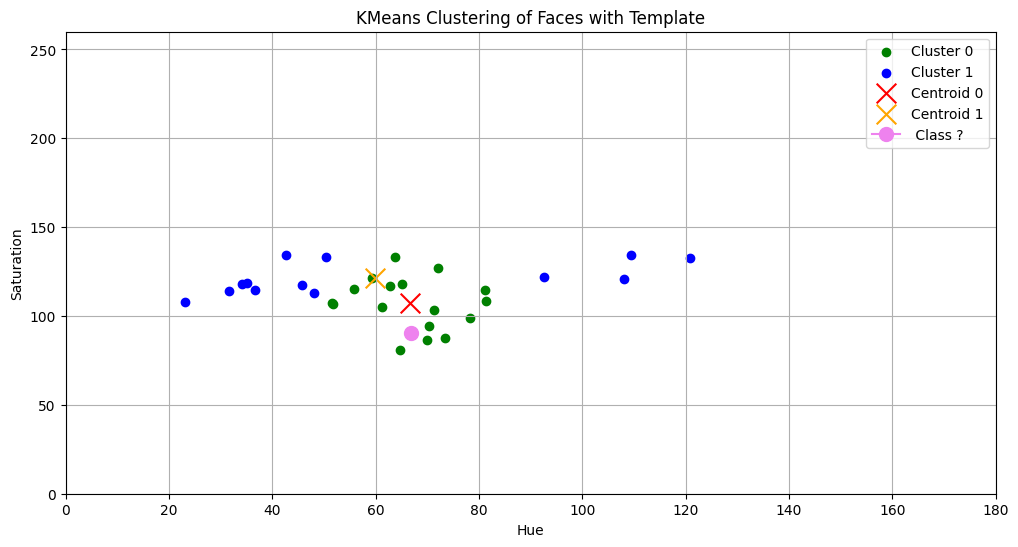

In [29]:
# Create an empty list to store legend labels
legend_labels = []

# Create lists to store points for each cluster
cluster_0_points = []
cluster_1_points = []

# Your code for scatter plot goes here
fig, ax = plt.subplots(figsize=(12, 6))
for i, (x, y, w, h) in enumerate(faces_rect):
    if kmeans.labels_[i] == 0:
        cluster_0_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))
    else:
        cluster_1_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))

# Plot points for cluster 0 in green
cluster_0_points = np.array(cluster_0_points)
plt.scatter(cluster_0_points[:, 0], cluster_0_points[:, 1],color='green', label='Cluster 0')


# Plot points for cluster 1 in blue
cluster_1_points = np.array(cluster_1_points)
plt.scatter(cluster_1_points[:, 0], cluster_1_points[:, 1],color='blue', label='Cluster 1')

# Calculate and plot centroids for both the clusters
centroid_0 = np.mean(cluster_0_points, axis=0)
centroid_1 = np.mean(cluster_1_points, axis=0)
plt.scatter(centroid_0[0], centroid_0[1],marker='x', s=200, color='red', label='Centroid 0') ## plot for centroid 0
plt.scatter(centroid_1[0], centroid_1[1],marker='x', s=200, color='orange', label='Centroid 1')  ## plot for centroid 1
plt.plot(template_hue, template_saturation, marker='o', c= 'violet',markersize= 10, label=' Class ?' )

## Put x label
## Put y label
## Put title
## Add a legend
## Add grid
## show the plot
plt.xlabel("Hue")
plt.ylabel("Saturation")
plt.title("KMeans Clustering of Faces with Template")
plt.legend()
plt.grid(True)

plt.xlim(0, 180)
plt.ylim(0, 260)

plt.show()

                                            ## End of the lab 5 ##

## Report:
## Answer the following questions within your report:


#### 1. What are the common distance metrics used in distance-based classification algorithms?
Euclidean Distance

Mahalanobis Distance

Manhattan Distance

Chebyshev Distance

Minkowski Distance

Cosine Distance

Hamming Distance

#### 2. What are some real-world applications of distance-based classification algorithms? 
Customer Behavior Prediction

Document Classification

Spam Filtering

Image Classification

Face Recognition

Product Categorization

Malware Categorization

Image Sentiment Analysis

Emotion Classification

Anomaly and Fraud Detection

Credit Worthiness Assessment

Language Sentiment Analysis

Disease Classification

#### 3. Explain various distance metrics. 
Euclidean Distance: Represents the shortest distance between two vectors. Most widely used. Easy to calculate. Does not account for data distribution.

Mahalanobis Distance: Measures distance between a point and a distribution. Takes variance and correlations into account. Scale-invariant.

Manhattan Distance: Distance measured along axes at right angles. Works better in very high-dimensional spaces.

Chebyshev Distance: Distance defined as the greatest difference along any coordinate dimension.

Minkowski Distance: Generalized distance metric.

p = 1 → Manhattan

p = 2 → Euclidean

p = ∞ → Chebyshev

Cosine Distance: Measures angle between vectors. Used when magnitude does not matter but orientation does.

Hamming Distance: Counts number of differing positions between two strings or bits.

#### 4. What is the role of cross validation in model performance? 
Training and validation set is randomly broken multiple times to validate the ML model again and again before testing on the test set.

#### 5. Explain variance and bias in terms of KNN? 
High value of K → Increases bias

Low value of K → Increases variance